# Decision Trees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz')
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 50000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz')
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 50000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz')
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 50000)
y_test shape: (20000,)


## Decision Tree Model Training

In [6]:
# Train Decision Tree Classifier
print("Training Decision Tree Classifier...")
start_time = time.time()
dt_classifier = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
)
dt_classifier.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training Decision Tree Classifier...
Training completed in 12.0094 seconds


## Model Evaluation

In [7]:
# Make predictions
y_pred = dt_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("DECISION TREE CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

DECISION TREE CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.7361
Precision: 0.7541
Recall:    0.6982
F1-Score:  0.7251
Training Time: 12.0094 seconds


## Classification Report

In [8]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.70      0.73      9966
    Positive       0.72      0.77      0.75     10034

    accuracy                           0.74     20000
   macro avg       0.74      0.74      0.74     20000
weighted avg       0.74      0.74      0.74     20000



## Confusion Matrix Visualization

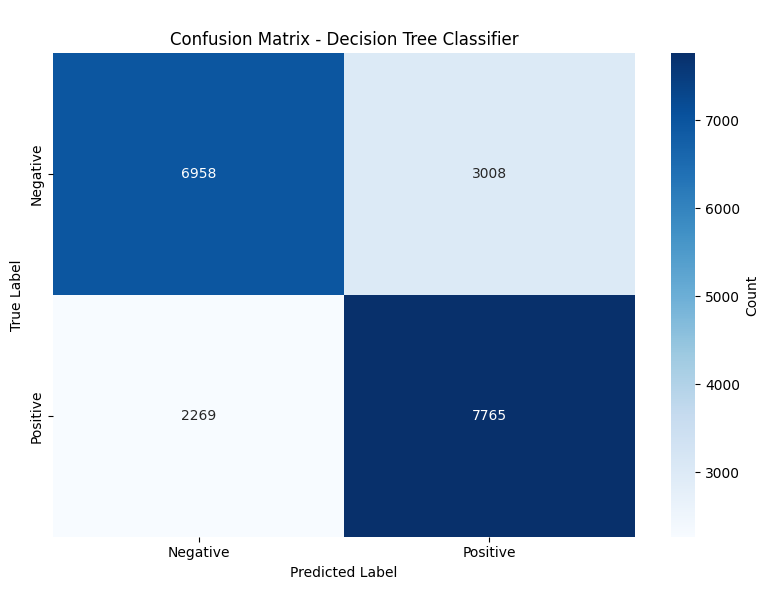

Confusion Matrix:
[[6958 3008]
 [2269 7765]]

True Negatives: 6958
False Positives: 3008
False Negatives: 2269
True Positives: 7765


In [9]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - Decision Tree Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('decision_tree_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Importance

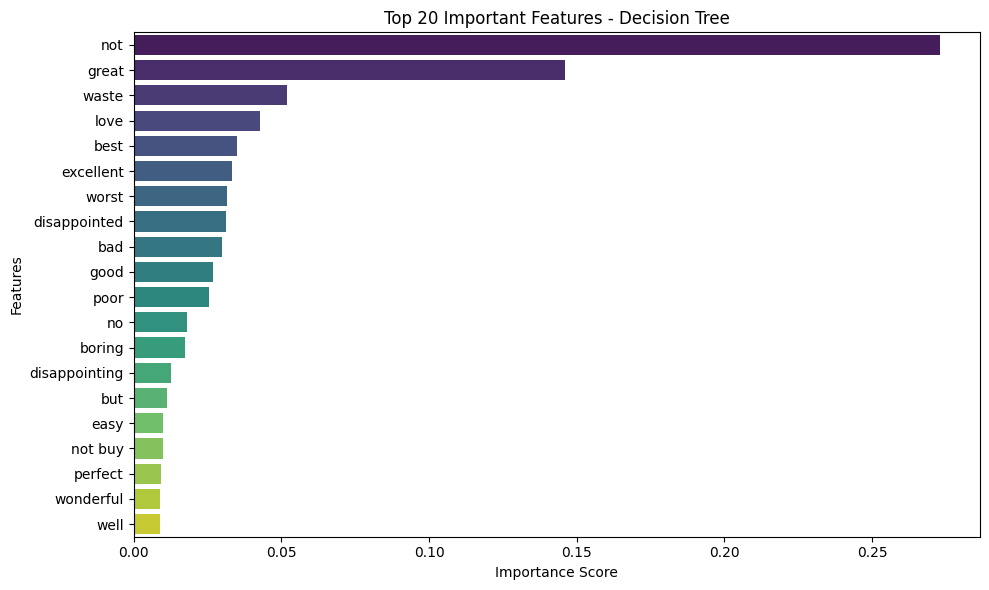


Top 20 Important Features:
      feature  importance
          not    0.272860
        great    0.146171
        waste    0.051754
         love    0.042831
         best    0.035120
    excellent    0.033444
        worst    0.031452
 disappointed    0.031242
          bad    0.029853
         good    0.027023
         poor    0.025409
           no    0.018160
       boring    0.017342
disappointing    0.012568
          but    0.011386
         easy    0.010087
      not buy    0.009815
      perfect    0.009278
    wonderful    0.008972
         well    0.008845


In [10]:
# Get feature importance
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_importance = dt_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Important Features - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('decision_tree_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## Model Summary

In [11]:
print("DECISION TREE MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Max Depth: {dt_classifier.max_depth}")
print(f"  - Min Samples Split: {dt_classifier.min_samples_split}")
print(f"  - Min Samples Leaf: {dt_classifier.min_samples_leaf}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")

DECISION TREE MODEL SUMMARY

Model Parameters:
  - Max Depth: 15
  - Min Samples Split: 10
  - Min Samples Leaf: 5

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.7361
  - Precision: 0.7541
  - Recall:    0.6982
  - F1-Score:  0.7251
  - Training Time: 12.0094 seconds
